# Mango Fruit Disease detection model

## Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.image import imread
from PIL import Image
import tensorflow as tf
from keras.preprocessing import image
from tensorflow.keras.utils import img_to_array, array_to_img
from keras.models import Sequential
from tensorflow import keras
from keras.layers import Conv2D,MaxPooling2D,Activation,Flatten,Dense,Dropout
from tensorflow.keras import layers
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

In [2]:
print(tf.__version__)

2.20.0


## create a dataset

In [3]:
batch_size = 32
img_height = 224
img_width = 224

# Split training folder into train and validation
train_image_dataset = tf.keras.utils.image_dataset_from_directory(
    "mango_dataset",
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=(img_height, img_width),
    batch_size=batch_size
)

val_image_dataset = tf.keras.utils.image_dataset_from_directory(
    "mango_dataset",
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=(img_height, img_width),
    batch_size=batch_size
)

# Test dataset (NO SPLIT HERE)
test_image_dataset = tf.keras.utils.image_dataset_from_directory(
    "mango_dataset",
    image_size=(img_height, img_width),
    batch_size=batch_size
)


class_names = train_image_dataset.class_names
num_classes = len(class_names)
class_name = {}
for i in range(len(class_names)):
    class_name[i + 1] = class_names[i]

print(class_names)
print(class_name)

Found 5000 files belonging to 5 classes.
Using 4000 files for training.
Found 5000 files belonging to 5 classes.
Using 1000 files for validation.
Found 5000 files belonging to 5 classes.
['Alternaria', 'Anthracnose', 'Black Mould Rot', 'Healthy', 'Stem end Rot']
{1: 'Alternaria', 2: 'Anthracnose', 3: 'Black Mould Rot', 4: 'Healthy', 5: 'Stem end Rot'}


##  Visualize the data

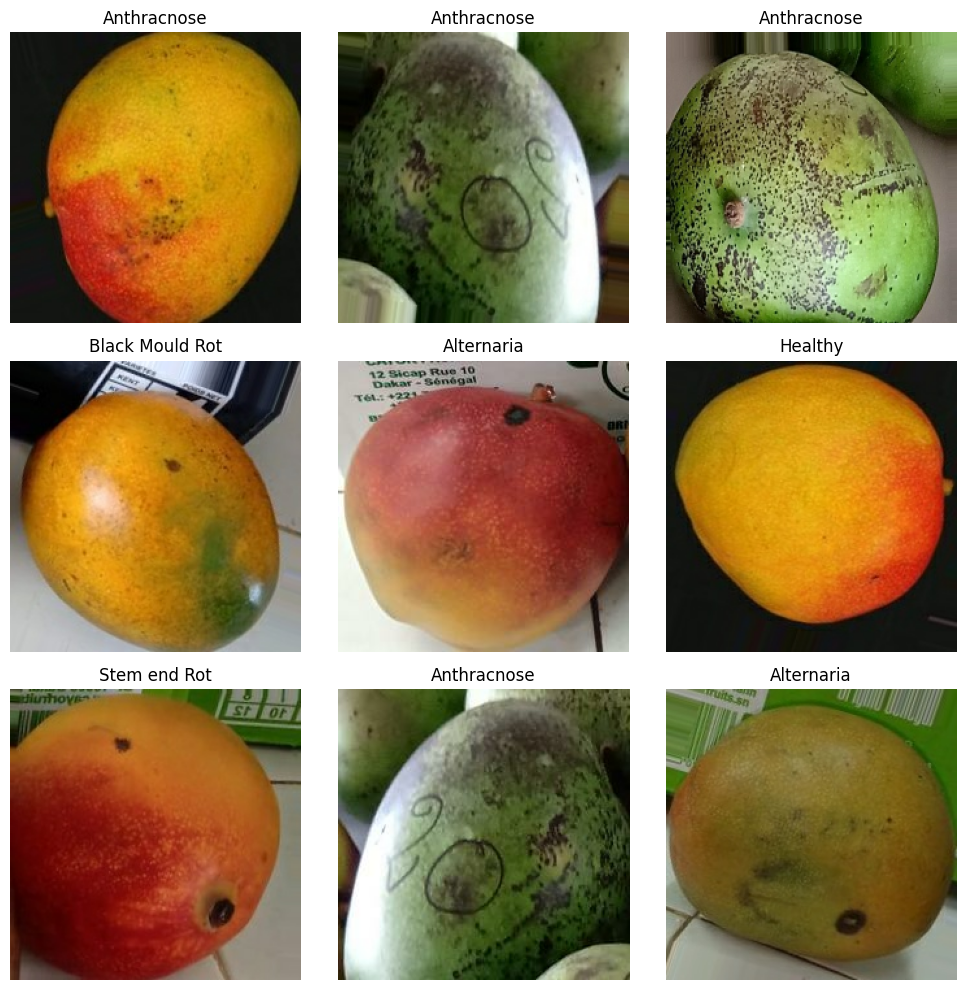

In [4]:
# Visualize the data (Fixed Version)

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 10))

for images, labels in train_image_dataset.take(1):  # Take only one batch
    for i in range(9):  # Show first 9 images
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i]])
        plt.axis("off")

plt.tight_layout()
plt.show()


Data Augmentation

In [5]:
image_batch, labels_batch = next(iter(train_image_dataset))
print(image_batch.shape)
print(labels_batch.shape)


(32, 224, 224, 3)
(32,)


##  creating CNN model

In [6]:
from tensorflow.keras import layers, Sequential
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

num_classes = len(class_names)

# 1️⃣ Load base model FIRST
base_model = MobileNetV2(
    input_shape=(img_height, img_width, 3),
    include_top=False,
    weights='imagenet'
)

base_model.trainable = False

# 2️⃣ Data augmentation
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.3),
    layers.RandomZoom(0.3),
    layers.RandomContrast(0.2),
])

# 3️⃣ Build final model
model = Sequential([
    layers.Input(shape=(img_height, img_width, 3)),
    data_augmentation,
    layers.Lambda(preprocess_input),

    base_model,   # ✅ Now it exists

    layers.GlobalAveragePooling2D(),
    layers.BatchNormalization(),

    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),

    layers.Dense(num_classes, activation='softmax')
])

##  compile the model

In [7]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4), 
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [8]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lambda (Lambda)                 │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │         1,285 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,592,325 (9.89 MB)

 Trainable params: 331,781 (1.27 MB)

 Non-trainable params: 2,260,544 (8.62 MB)

##  Train the model

In [9]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

epochs = 30

history = model.fit(
    train_image_dataset,
    validation_data=val_image_dataset,
    epochs=epochs,
    callbacks=[early_stop]
)


Epoch 1/30
125/125 ━━━━━━━━━━━━━━━━━━━━ 106s 797ms/step - accuracy: 0.5393 - loss: 1.3090 - val_accuracy: 0.7860 - val_loss: 0.6549
Epoch 2/30
125/125 ━━━━━━━━━━━━━━━━━━━━ 100s 800ms/step - accuracy: 0.6985 - loss: 0.8517 - val_accuracy: 0.8260 - val_loss: 0.4857
Epoch 3/30
125/125 ━━━━━━━━━━━━━━━━━━━━ 91s 727ms/step - accuracy: 0.7465 - loss: 0.7212 - val_accuracy: 0.8400 - val_loss: 0.4252
Epoch 4/30
125/125 ━━━━━━━━━━━━━━━━━━━━ 93s 746ms/step - accuracy: 0.7720 - loss: 0.6650 - val_accuracy: 0.8560 - val_loss: 0.3830
Epoch 5/30
125/125 ━━━━━━━━━━━━━━━━━━━━ 90s 721ms/step - accuracy: 0.7730 - loss: 0.6264 - val_accuracy: 0.8710 - val_loss: 0.3505
Epoch 6/30
125/125 ━━━━━━━━━━━━━━━━━━━━ 85s 681ms/step - accuracy: 0.7928 - loss: 0.5628 - val_accuracy: 0.8860 - val_loss: 0.3286
Epoch 7/30
125/125 ━━━━━━━━━━━━━━━━━━━━ 86s 689ms/step - accuracy: 0.7940 - loss: 0.5385 - val_accuracy: 0.8870 - val_loss: 0.3139
Epoch 8/30
125/125 ━━━━━━━━━━━━━━━━━━━━ 94s 754ms/step - accuracy: 0.8020 - loss:

Fine Tuning

In [10]:
# -------- Fine Tuning -------- #

# Unfreeze base model
base_model.trainable = True

# Freeze first layers, train last 40 layers
for layer in base_model.layers[:-40]:
    layer.trainable = False

Recompile

In [11]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=5e-6),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

Fine Tune Training

In [12]:
history_fine = model.fit(
    train_image_dataset,
    validation_data=val_image_dataset,
    epochs=8,
    callbacks=[early_stop]
)

Epoch 1/8
125/125 ━━━━━━━━━━━━━━━━━━━━ 243s 2s/step - accuracy: 0.7308 - loss: 0.7629 - val_accuracy: 0.8900 - val_loss: 0.2888
Epoch 2/8
125/125 ━━━━━━━━━━━━━━━━━━━━ 110s 881ms/step - accuracy: 0.7738 - loss: 0.6336 - val_accuracy: 0.8670 - val_loss: 0.3713
Epoch 3/8
125/125 ━━━━━━━━━━━━━━━━━━━━ 104s 835ms/step - accuracy: 0.7900 - loss: 0.6047 - val_accuracy: 0.8700 - val_loss: 0.3613
Epoch 4/8
125/125 ━━━━━━━━━━━━━━━━━━━━ 105s 839ms/step - accuracy: 0.7972 - loss: 0.5619 - val_accuracy: 0.8770 - val_loss: 0.3320
Epoch 5/8
125/125 ━━━━━━━━━━━━━━━━━━━━ 104s 829ms/step - accuracy: 0.8217 - loss: 0.5222 - val_accuracy: 0.8830 - val_loss: 0.2996


Evaluation cell

In [13]:
test_loss, test_accuracy = model.evaluate(val_image_dataset)

print("Validation Accuracy:", test_accuracy)
print("Validation Loss:", test_loss)

32/32 ━━━━━━━━━━━━━━━━━━━━ 15s 481ms/step - accuracy: 0.8900 - loss: 0.2888
Validation Accuracy: 0.8899999856948853
Validation Loss: 0.2887685000896454


##  Predict the new data

In [14]:
# Define the path where you want to save the model

model.save('Mango_Fruit_Detection_Model.h5')


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 170ms/step


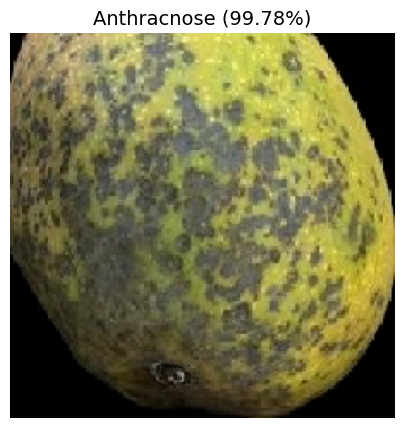



 ****** Mango Fruit Disease Detection ****** 

Predicted Disease: Anthracnose


In [17]:
import matplotlib.pyplot as plt
import numpy as np
from tensorflow.keras.preprocessing import image

# Give correct path
test_image_path = "test/download_file.jpg"

# Load image
img = image.load_img(test_image_path, target_size=(224, 224))

# Convert for model
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)

# Predict
prediction = model.predict(img_array)
predicted_class = np.argmax(prediction)

disease_name = class_names[predicted_class]
confidence = np.max(prediction) * 100

# =========================
# DISPLAY IMAGE + RESULT
# =========================
plt.figure(figsize=(5,5))

plt.imshow(img)
plt.axis("off")

plt.title(f"{disease_name} ({confidence:.2f}%)", fontsize=14)

plt.show()

# Console output
print("\n\n ****** Mango Fruit Disease Detection ****** \n")
print("Predicted Disease:", disease_name)
